In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv")
print(df.shape)
df.head()

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Eksik veri analizi
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Eksik Sayı": missing, "Eksik Oran (%)": missing_pct})
missing_df = missing_df[missing_df["Eksik Sayı"] > 0].sort_values("Eksik Sayı", ascending=False)
print(missing_df)

            Eksik Sayı  Eksik Oran (%)
director          2634           29.91
country            831            9.44
cast               825            9.37
date_added          10            0.11
rating               4            0.05
duration             3            0.03


In [4]:
# Eksik verileri doldur
df["director"].fillna("Bilinmiyor", inplace=True)
df["cast"].fillna("Bilinmiyor", inplace=True)
df["country"].fillna("Bilinmiyor", inplace=True)
df["rating"].fillna(df["rating"].mode()[0], inplace=True)
df["date_added"].fillna("Bilinmiyor", inplace=True)
df.dropna(subset=["duration"], inplace=True)

# Yeni sütunlar
df["year_added"] = pd.to_numeric(df["date_added"].str.strip().str[-4:], errors="coerce")
df["duration_val"] = df["duration"].str.extract(r"(\d+)").astype(float)

print("Temizleme sonrası eksik değer:")
print(df.isnull().sum())
print("\nYeni shape:", df.shape)

Temizleme sonrası eksik değer:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      10
duration_val     0
dtype: int64

Yeni shape: (8804, 14)


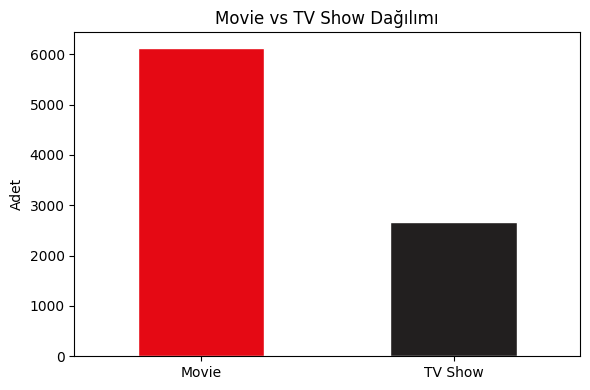

In [5]:
# 1. Hedef değişken dağılımı
plt.figure(figsize=(6,4))
df["type"].value_counts().plot(kind="bar", color=["#e50914","#221f1f"], edgecolor="white")
plt.title("Movie vs TV Show Dağılımı")
plt.xlabel("")
plt.ylabel("Adet")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

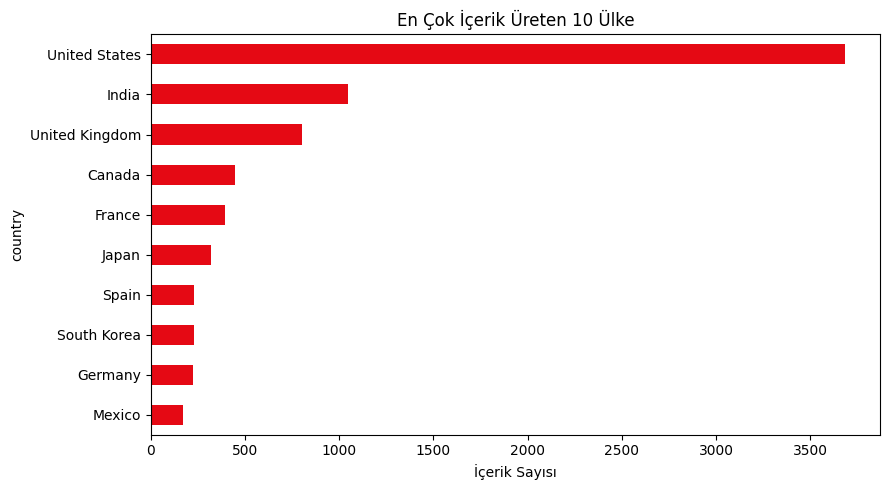

In [6]:
# En çok içerik üreten 10 ülke
top_countries = (df[df["country"] != "Bilinmiyor"]["country"]
                 .str.split(", ").explode()
                 .value_counts().head(10))

plt.figure(figsize=(9,5))
top_countries.sort_values().plot(kind="barh", color="#e50914")
plt.title("En Çok İçerik Üreten 10 Ülke")
plt.xlabel("İçerik Sayısı")
plt.tight_layout()
plt.show()

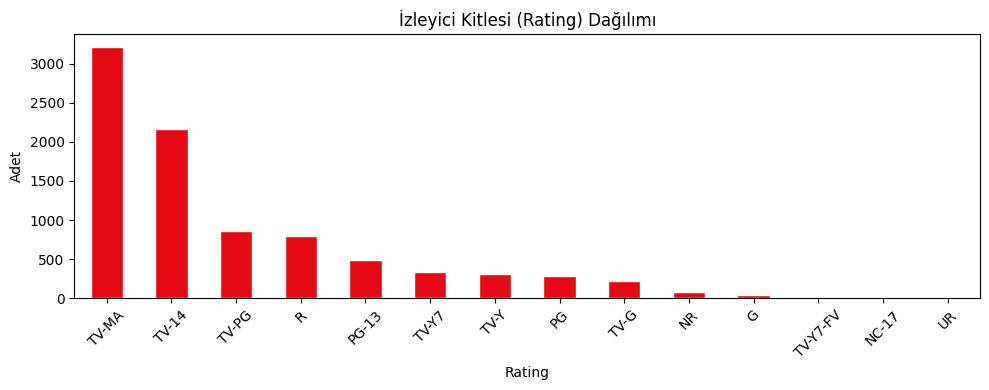

In [7]:
# Rating dağılımı
plt.figure(figsize=(10,4))
df["rating"].value_counts().plot(kind="bar", color="#e50914", edgecolor="white")
plt.title("İzleyici Kitlesi (Rating) Dağılımı")
plt.xlabel("Rating")
plt.ylabel("Adet")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()